# 12e — ND-GAIN Country Vulnerability Index

Covers `chap12_ext_ndgain_country1` through `ext_ndgain_country5`: the
Notre Dame Global Adaptation Initiative (ND-GAIN) country index, which
combines a *Vulnerability* score (how exposed/sensitive a country is to
climate hazards, and how much adaptive capacity it lacks, broken into 6
sectors — ecosystems, food, habitat, health, infrastructure, water) with a
*Readiness* score (how well-positioned its economy/governance/society is
to deploy adaptation investment) into an overall *Gain* score.

**Data note:** every script here indexes country rows as `T{2:end,pos}` —
in MATLAB's 1-based indexing, that skips the table's first data row,
which is Afghanistan (alphabetically first in every sheet). This is
reproduced faithfully (`.iloc[1:]`) rather than "corrected," since we want
this notebook's tables and rankings to match what the book's own figures
show; it may be a deliberate exclusion (a known ND-GAIN data-quality flag
on early Afghanistan estimates) or an off-by-one slip in the source
scripts that just never mattered enough to notice across ~190 countries —
either way, disclosed here rather than silently changed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../../data"

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_violet = "#9467bd"
color_teal   = "#17becf"

plt.rcParams["figure.dpi"] = 100


In [2]:
SHEETS = ["gain", "vulnerability", "capacity", "exposure", "sensitivity",
          "readiness", "ecosystems", "food", "habitat", "health",
          "infrastructure", "water"]
TABLES = {s: pd.read_excel(f"{DATA_DIR}/chap12_ext_ndgain_country_index.xlsx", sheet_name=s)
          for s in SHEETS}
# Skip the first data row (Afghanistan) in every table, matching the
# source scripts' `T{2:end,pos}` MATLAB indexing (see note above).
DATA = {s: df.iloc[1:].reset_index(drop=True) for s, df in TABLES.items()}
LATEST_YEAR = TABLES["vulnerability"].columns[-1]
print(f"Latest year column: {LATEST_YEAR}, {len(DATA['vulnerability'])} countries (Afghanistan excluded)")


Latest year column: 2023, 191 countries (Afghanistan excluded)


## 1. Sector correlation structure (`chap12_ext_ndgain_country1`)

How correlated is each of the 6 sector-level vulnerability scores with the
aggregate Vulnerability score, and with each other — all evaluated in the
latest available year.

In [3]:
SECTORS = ["ecosystems", "food", "habitat", "health", "infrastructure", "water"]
sector_labels = ["Ecosystems", "Food", "Habitat", "Health", "Infrastructure", "Water", "Aggregate"]

corr_input = pd.DataFrame({lbl: DATA[s][LATEST_YEAR].values for s, lbl in zip(SECTORS, sector_labels[:-1])})
corr_input["Aggregate"] = DATA["vulnerability"][LATEST_YEAR].values

rho = corr_input.corr()  # pandas .corr() uses pairwise-complete-observations, matching MATLAB's 'pairwise'
display((100 * rho).round(1))


,Ecosystems,Food,Habitat,Health,Infrastructure,Water,Aggregate
Ecosystems,100.0,59.5,38.6,64.1,1.4,25.9,69.7
Food,59.5,100.0,39.1,84.5,10.5,38.6,84.1
Habitat,38.6,39.1,100.0,52.3,2.6,11.5,56.9
Health,64.1,84.5,52.3,100.0,18.6,37.0,90.8
Infrastructure,1.4,10.5,2.6,18.6,100.0,17.9,45.8
Water,25.9,38.6,11.5,37.0,17.9,100.0,53.0
Aggregate,69.7,84.1,56.9,90.8,45.8,53.0,100.0


## 2. Sector vs. aggregate vulnerability scatter (`chap12_ext_ndgain_country2`)

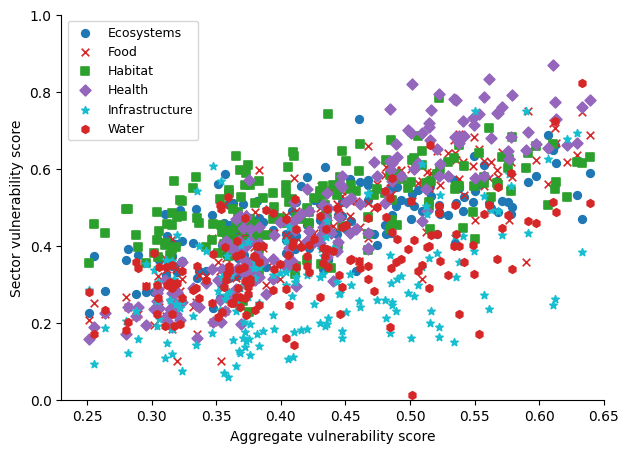

In [4]:
x = DATA["vulnerability"][LATEST_YEAR].values
markers = [("o", color_blue), ("x", color_red), ("s", color_green),
           ("D", color_violet), ("*", color_teal), ("h", color_red)]

fig, ax = plt.subplots(figsize=(7, 5))
for (s, lbl), (marker, c) in zip(zip(SECTORS, sector_labels[:-1]), markers):
    y = DATA[s][LATEST_YEAR].values
    if marker in ("x", "*"):
        ax.scatter(x, y, s=30, marker=marker, color=c, linewidths=1.2, label=lbl)
    else:
        ax.scatter(x, y, s=30, marker=marker, facecolors=c, edgecolors=c, linewidths=1.2, label=lbl)

ax.set_xlabel("Aggregate vulnerability score")
ax.set_ylabel("Sector vulnerability score")
ax.set_xlim(0.23, 0.65)
ax.set_ylim(0.0, 1.0)
ax.legend(fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


## 3. Vulnerability vs. readiness, 1995 vs. 2023 (`chap12_ext_ndgain_country3`)

Correlation between Vulnerability and Readiness in 1995 and in 2023
(nearly three decades apart), plus a subset correlation restricting to
the more-vulnerable half of countries (2023 vulnerability $>0.45$) — do
the most-vulnerable countries show a different relationship?

1995 correlation (vulnerability, readiness):
[[ 1.         -0.60808397]
 [-0.60808397  1.        ]]
2023 correlation (vulnerability, readiness):
[[ 1.         -0.63437228]
 [-0.63437228  1.        ]]
2023 correlation, vulnerability > 0.45 only (72 countries):
[[ 1.         -0.08111172]
 [-0.08111172  1.        ]]


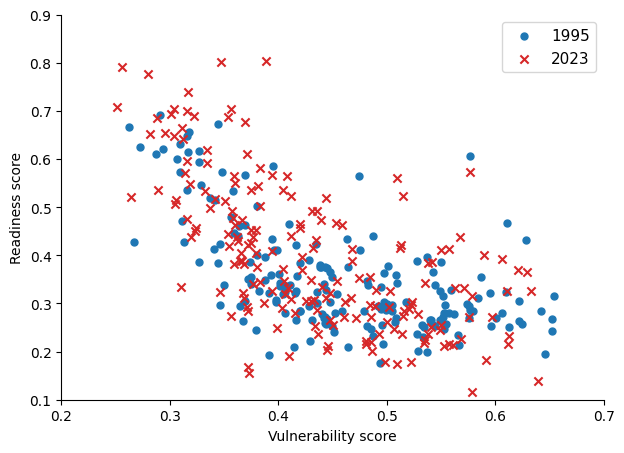

In [5]:
FIRST_YEAR = TABLES["vulnerability"].columns[2]  # first year column after ISO3, Name
x = DATA["vulnerability"][[FIRST_YEAR, LATEST_YEAR]].values
y = DATA["readiness"][[FIRST_YEAR, LATEST_YEAR]].values

rho_1995 = np.corrcoef(x[:, 0][~np.isnan(x[:, 0]) & ~np.isnan(y[:, 0])],
                        y[:, 0][~np.isnan(x[:, 0]) & ~np.isnan(y[:, 0])])
print(f"{FIRST_YEAR} correlation (vulnerability, readiness):\n{rho_1995}")

mask_2023 = ~np.isnan(x[:, 1]) & ~np.isnan(y[:, 1])
rho_2023 = np.corrcoef(x[:, 1][mask_2023], y[:, 1][mask_2023])
print(f"{LATEST_YEAR} correlation (vulnerability, readiness):\n{rho_2023}")

hi_vuln = mask_2023 & (x[:, 1] > 0.45)
rho_2023_hi = np.corrcoef(x[:, 1][hi_vuln], y[:, 1][hi_vuln])
print(f"{LATEST_YEAR} correlation, vulnerability > 0.45 only ({hi_vuln.sum()} countries):\n{rho_2023_hi}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x[:, 0], y[:, 0], s=25, color=color_blue, label=str(FIRST_YEAR))
ax.scatter(x[:, 1], y[:, 1], s=35, marker="x", color=color_red, linewidths=1.5, label=str(LATEST_YEAR))
ax.set_xlabel("Vulnerability score")
ax.set_ylabel("Readiness score")
ax.set_xlim(0.2, 0.7)
ax.set_ylim(0.1, 0.9)
ax.legend(fontsize=11, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


## 4. Most and least vulnerable countries (`chap12_ext_ndgain_country4`)

The 10 highest- and 10 lowest-`Vulnerability`-score countries in
2023.

In [6]:
T = DATA["vulnerability"]
x = T[LATEST_YEAR]
country = T["Name"]

top10 = x.sort_values(ascending=False, na_position="last").head(10)
print(f"Most vulnerable (top 10, {LATEST_YEAR}):")
display(pd.DataFrame({"Country": country.loc[top10.index], "Vulnerability": top10.round(2)}).reset_index(drop=True))

bottom10 = x.sort_values(ascending=True, na_position="last").head(10)
print(f"Least vulnerable (bottom 10, {LATEST_YEAR}):")
display(pd.DataFrame({"Country": country.loc[bottom10.index], "Vulnerability": bottom10.round(2)}).reset_index(drop=True))


Most vulnerable (top 10, 2023):


,Country,Vulnerability
0,Chad,0.64
1,Niger,0.63
2,Solomon Islands,0.63
3,"Micronesia, Federated States of",0.62
4,Guinea-Bissau,0.61
5,Sudan,0.61
6,Somalia,0.61
7,Tonga,0.61
8,Sierra Leone,0.60
9,Eritrea,0.59


Least vulnerable (bottom 10, 2023):


,Country,Vulnerability
0,Switzerland,0.25
1,Norway,0.26
2,Czech Republic,0.26
3,Finland,0.28
4,Canada,0.28
5,United Kingdom,0.29
6,Israel,0.29
7,Austria,0.30
8,Germany,0.30
9,France,0.30


## 5. Highest and lowest overall ND-GAIN Gain score (`chap12_ext_ndgain_country5`)

The same ranking, for the overall (readiness-adjusted) `Gain` score —
higher is better here (more ready to translate investment into reduced
vulnerability), the opposite sense from `Vulnerability` above.

In [7]:
T = DATA["gain"]
x = T[LATEST_YEAR]
country = T["Name"]

top10 = x.sort_values(ascending=False, na_position="last").head(10)
print(f"Highest ND-GAIN score (top 10, {LATEST_YEAR}):")
display(pd.DataFrame({"Country": country.loc[top10.index], "Gain": top10.round(2)}).reset_index(drop=True))

bottom10 = x.sort_values(ascending=True, na_position="last").head(10)
print(f"Lowest ND-GAIN score (bottom 10, {LATEST_YEAR}):")
display(pd.DataFrame({"Country": country.loc[bottom10.index], "Gain": bottom10.round(2)}).reset_index(drop=True))


Highest ND-GAIN score (top 10, 2023):


,Country,Gain
0,Norway,76.79
1,Finland,74.79
2,Switzerland,72.89
3,Denmark,72.75
4,Sweden,71.10
5,Singapore,70.79
6,New Zealand,70.03
7,United Kingdom,69.85
8,Germany,69.61
9,Australia,69.20


Lowest ND-GAIN score (bottom 10, 2023):


,Country,Gain
0,Chad,24.99
1,Central African Republic,26.87
2,Eritrea,29.53
3,Sudan,30.19
4,Guinea-Bissau,30.96
5,"Congo, the Democratic Republic o",32.66
6,Congo,32.79
7,Bangladesh,32.86
8,Burundi,32.88
9,Madagascar,32.96
